<a href="https://colab.research.google.com/github/pxtroniwnl/barcelona-de-indias-time-serie/blob/main/precipitacioonIDEAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Precipitación — estaciones IDEAM cercanas al ROI de la laguna

**Fuente:** CSV del IDEAM, departamento de Bolívar, sensor de precipitación (`0240`, unidad `mm`).
**Objetivo:** Identificar las 2 estaciones más cercanas al ROI de la laguna Barcelona de Indias, limpiar y analizar sus series de precipitación y exportarlas en formato nativo, horario y diario.

## 1. Configuración

In [1]:
import math
from pathlib import Path

import folium
from folium.plugins import Fullscreen
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Rutas locales
RUTA_CSV = Path("data/ideam/Precipitación_20260818_SOLO_BOLIVAR.csv")

# Formato de fecha del IDEAM
FORMATO_FECHA = "%Y %b %d %I:%M:%S %p"

# Columnas categóricas a conservar como texto
DTYPES_TEXTO = {"CodigoEstacion": "string", "CodigoSensor": "string"}

COLS_TEXTO = [
    "CodigoEstacion", "CodigoSensor", "NombreEstacion", "Departamento",
    "Municipio", "ZonaHidrografica", "DescripcionSensor", "UnidadMedida",
]

# Control de calidad y umbrales
RANGO_PP_VALIDO = (0.0, 100.0)  # Lámina en un intervalo de muestreo (mm)
UMBRAL_PP_SOSPECHOSO = 25.0     # mm en un solo intervalo
MM_INTERVALO_HUMEDO = 0.1       # Umbral para considerar que un intervalo registró lluvia
FACTOR_HUECO = 3                # Salto > FACTOR_HUECO x paso se considera interrupción
PASO_FALLBACK_S = 600.0         # 10 min por defecto

# ROI de la laguna Barcelona de Indias (longitud, latitud)
ROI_COORDS = [
    [-75.476052, 10.517524],
    [-75.476117, 10.518747],
    [-75.473158, 10.519223],
    [-75.470516, 10.525108],
    [-75.469572, 10.524876],
    [-75.471686, 10.518916],
    [-75.468394, 10.517219],
    [-75.468952, 10.516459],
]

FACTORES = [1, 2, 3, 4]
COLORES_CAJA = {1: "red", 2: "orange", 3: "gold", 4: "green"}
N_ESTACIONES = 2  # Las 2 estaciones más cercanas al ROI
TOL_SITIO = 3     # decimales de redondeo para colapsar sitios físicos (≈ 110 m)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

## 2. Carga del CSV crudo

Se carga directamente utilizando el motor C optimizado de `pandas`.
Permite leer más de 5 millones de filas en pocos segundos en memoria local sin saturar la RAM.

In [2]:
def cargar_crudo(ruta: Path) -> pd.DataFrame:
    """Carga el CSV del IDEAM de forma directa y eficiente con motor C de pandas."""
    return pd.read_csv(ruta, dtype=DTYPES_TEXTO, encoding="utf-8-sig", low_memory=False)


df_raw = cargar_crudo(RUTA_CSV)
print(f"{len(df_raw):,} filas × {df_raw.shape[1]} columnas")
df_raw.head(3)

5,046,625 filas × 12 columnas


,CodigoEstacion,CodigoSensor,FechaObservacion,ValorObservado,NombreEstacion,Departamento,Municipio,ZonaHidrografica,Latitud,Longitud,DescripcionSensor,UnidadMedida
0,0023207040,0240,2017 Mar 30 06:10:00 PM,0.0,SAN PABLO RIO MAGDALENA - AUT,BOLIVAR,SAN PABLO,MEDIO MAGDALENA,7.480333,-73.918556,Precipitacion,mm
1,0029015000,0240,2019 Jul 21 09:20:00 AM,0.0,EL GUAMO - AUT,BOLIVAR,EL GUAMO,BAJO MAGDALENA,10.064444,-74.852222,Precipitacion,mm
2,0029015000,0240,2019 Aug 07 09:40:00 PM,0.0,EL GUAMO - AUT,BOLIVAR,EL GUAMO,BAJO MAGDALENA,10.064444,-74.852222,Precipitacion,mm


In [3]:
for col in ["UnidadMedida", "DescripcionSensor", "CodigoSensor", "Departamento"]:
    vals = sorted(df_raw[col].dropna().unique().tolist())
    print(f"{col:20s} ({len(vals):>3}): {vals[:6]}{' …' if len(vals) > 6 else ''}")

print()
print(df_raw.dtypes)

UnidadMedida         (  1): ['mm']


DescripcionSensor    (  3): ['GPRS - PRECIPITACIÓN', 'PRECIPITACIÓN', 'Precipitacion']


CodigoSensor         (  2): ['0240', '0257']


Departamento         (  3): ['BOLIVAR', 'BOLÍVAR', 'Bolivar']

CodigoEstacion        string
CodigoSensor          string
FechaObservacion         str
ValorObservado       float64
NombreEstacion           str
Departamento             str
Municipio                str
ZonaHidrografica         str
Latitud              float64
Longitud             float64
DescripcionSensor        str
UnidadMedida             str
dtype: object


## 3. Limpieza

Operaciones de control de calidad:
1. Normalización de texto en columnas categóricas.
2. Parseo de fechas.
3. Control de rango físico (0.0 a 100.0 mm por intervalo; centinelas -9999 pasan a NaN).
4. Desduplicación determinista por `(CodigoEstacion, FechaObservacion)`.

In [4]:
def limpiar(df_raw: pd.DataFrame) -> pd.DataFrame:
    """Normaliza texto, parsea fechas, aplica QC de rango y desduplica."""
    df = df_raw.copy()

    # 1. texto
    for c in COLS_TEXTO:
        if c in df.columns:
            df[c] = df[c].astype("string").str.strip().str.replace(r"\s+", " ", regex=True)

    # 2. fecha
    df["FechaObservacion"] = pd.to_datetime(df["FechaObservacion"], format=FORMATO_FECHA, errors="coerce")

    # 3. rango físico
    lo, hi = RANGO_PP_VALIDO
    df["ValorObservado"] = pd.to_numeric(df["ValorObservado"], errors="coerce")
    df.loc[~df["ValorObservado"].between(lo, hi), "ValorObservado"] = np.nan

    # 4. desduplicación
    df = (
        df.sort_values(["CodigoEstacion", "FechaObservacion", "CodigoSensor"], kind="stable")
        .drop_duplicates(subset=["CodigoEstacion", "FechaObservacion"], keep="first")
        .reset_index(drop=True)
    )
    return df


df = limpiar(df_raw)

print(f"crudo   : {len(df_raw):,}")
print(f"limpio  : {len(df):,}  ({len(df_raw) - len(df):,} duplicados eliminados)")
print(f"NaN QC  : {df['ValorObservado'].isna().sum():,} valores fuera de {RANGO_PP_VALIDO}")
df.dtypes

crudo   : 5,046,625
limpio  : 4,613,086  (433,539 duplicados eliminados)
NaN QC  : 0 valores fuera de (0.0, 100.0)


CodigoEstacion               string
CodigoSensor                 string
FechaObservacion     datetime64[us]
ValorObservado              float64
NombreEstacion               string
Departamento                 string
Municipio                    string
ZonaHidrografica             string
Latitud                     float64
Longitud                    float64
DescripcionSensor            string
UnidadMedida                 string
dtype: object

## 4. Catálogo de estaciones

Construcción del catálogo de estaciones determinista con coordenadas consolidadas.

In [5]:
def construir_catalogo(df: pd.DataFrame) -> pd.DataFrame:
    """Una fila por CodigoEstacion, con nombre canónico y coordenadas robustas."""
    conteo = (
        df.groupby(["CodigoEstacion", "NombreEstacion"], as_index=False)
        .size()
        .rename(columns={"size": "_n"})
    )
    nombre_canonico = (
        conteo.sort_values(
            ["CodigoEstacion", "_n", "NombreEstacion"],
            ascending=[True, False, True],
            kind="stable",
        )
        .drop_duplicates("CodigoEstacion", keep="first")
        .drop(columns="_n")
    )

    agregados = (
        df.groupby("CodigoEstacion")
        .agg(
            Municipio=("Municipio", lambda s: s.mode().iat[0]),
            ZonaHidrografica=("ZonaHidrografica", lambda s: s.mode().iat[0]),
            Latitud=("Latitud", "median"),
            Longitud=("Longitud", "median"),
            n_variantes_nombre=("NombreEstacion", "nunique"),
            n_sensores=("CodigoSensor", "nunique"),
            n_obs=("ValorObservado", "size"),
        )
        .reset_index()
    )

    return nombre_canonico.merge(agregados, on="CodigoEstacion", how="left")


catalogo = construir_catalogo(df)
print(f"{len(catalogo)} estaciones únicas de precipitación")
catalogo.sort_values("n_obs", ascending=False).head(10)

19 estaciones únicas de precipitación


,CodigoEstacion,NombreEstacion,Municipio,ZonaHidrografica,Latitud,Longitud,n_variantes_nombre,n_sensores,n_obs
2,0014015080,AEROPUERTO RAFAEL NUNEZ,CARTAGENA DE INDIAS,CARIBE - LITORAL,10.447250,-75.516028,2,2,730276
4,0014019030,CC DIQUE: CIOH,CARTAGENA DE INDIAS,CARIBE - LITORAL,10.391000,-75.534000,2,1,666859
3,0014017001,TESORO INVEMAR,CARTAGENA DE INDIAS,BAJO MAGDALENA,10.235000,-75.741000,1,1,323233
13,0029015000,EL GUAMO - AUT,EL GUAMO,BAJO MAGDALENA,10.064444,-74.852222,3,1,290353
14,0029015040,CARMEN DE BOLIVAR - AUT,EL CARMÉN DE BOLÍVAR,BAJO MAGDALENA,9.715750,-75.106417,3,1,286865
15,0029035000,SINCERIN - AUT,ARJONA,BAJO MAGDALENA,10.142583,-75.278278,3,1,274716
12,0025027910,LA RAYA,SAN JACINTO DEL CAUCA,CAUCA,8.344556,-74.561000,2,1,255491
16,1206500136,UNIVERSIDAD UNAD CARTAGENA - AUT,CARTAGENA DE INDIAS,CARIBE - LITORAL,10.400311,-75.513281,3,1,229591
1,0014015020,APTO RAFAEL NUÑEZ TX GPRS,CARTAGENA,CARIBE - LITORAL,10.447000,-75.516000,1,1,224941
10,0025027180,SAN ANTONIO,MAGANGUÉ,BAJO MAGDALENA- CAUCA -SAN JORGE,9.039073,-74.768000,2,1,218745


## 5. Geometría: ROI y cajas anidadas

In [6]:
# Centro y semiejes del bounding box del ROI (cálculo local)
_lons = [c[0] for c in ROI_COORDS]
_lats = [c[1] for c in ROI_COORDS]
CX, CY = (min(_lons) + max(_lons)) / 2, (min(_lats) + max(_lats)) / 2
HW, HH = (max(_lons) - min(_lons)) / 2, (max(_lats) - min(_lats)) / 2

BBOXES = {f: (CX - HW * f, CY - HH * f, CX + HW * f, CY + HH * f) for f in FACTORES}

print(f"Centro del ROI: lat={CY:.6f}, lon={CX:.6f}\n")
for f in FACTORES:
    x0, y0, x1, y1 = BBOXES[f]
    ancho = (x1 - x0) * 111.32 * math.cos(math.radians(CY))
    alto = (y1 - y0) * 111.32
    print(f"  {f}x → {ancho:5.2f} km × {alto:5.2f} km   (área ≈ {ancho*alto:5.2f} km²)")

Centro del ROI: lat=10.520784, lon=-75.472256

  1x →  0.85 km ×  0.96 km   (área ≈  0.81 km²)
  2x →  1.69 km ×  1.93 km   (área ≈  3.26 km²)
  3x →  2.54 km ×  2.89 km   (área ≈  7.32 km²)
  4x →  3.38 km ×  3.85 km   (área ≈ 13.02 km²)


## 6. Clasificación espacial y distancias

Cálculo de distancias esféricas al centroide y distancias mínimas al perímetro del polígono ROI.

In [7]:
def dist_haversine_km(lat, lon, lat0: float, lon0: float, R: float = 6371.0088) -> np.ndarray:
    """Distancia esférica desde cada punto hasta (lat0, lon0), en km. Vectorizada."""
    lat = np.asarray(lat, dtype=float)
    lon = np.asarray(lon, dtype=float)
    dphi = np.radians(lat0 - lat)
    dlam = np.radians(lon0 - lon)
    a = (
        np.sin(dphi / 2) ** 2
        + np.cos(np.radians(lat)) * math.cos(math.radians(lat0)) * np.sin(dlam / 2) ** 2
    )
    return 2 * R * np.arcsin(np.sqrt(a))


def clasificar_por_caja(df: pd.DataFrame) -> pd.Series:
    """Nivel de la caja más pequeña que contiene el punto; <NA> si ninguna."""
    nivel = pd.Series(pd.NA, index=df.index, dtype="Int32")
    for f in sorted(FACTORES, reverse=True):
        x0, y0, x1, y1 = BBOXES[f]
        dentro = df["Longitud"].between(x0, x1) & df["Latitud"].between(y0, y1)
        nivel = nivel.mask(dentro, f)
    return nivel


def _xy_local(lon, lat):
    km_lat = 111.32
    km_lon = 111.32 * math.cos(math.radians(CY))
    return np.array([(lon - CX) * km_lon, (lat - CY) * km_lat], dtype=float)


def _dist_punto_segmento(p, a, b) -> float:
    ab = b - a
    den = float(np.dot(ab, ab))
    t = 0.0 if den == 0 else float(np.clip(np.dot(p - a, ab) / den, 0, 1))
    return float(np.linalg.norm(p - (a + t * ab)))


def dist_borde_roi_km(lat: float, lon: float) -> float:
    coords = ROI_COORDS + [ROI_COORDS[0]]
    p = _xy_local(lon, lat)
    return min(
        _dist_punto_segmento(p, _xy_local(*coords[i]), _xy_local(*coords[i + 1]))
        for i in range(len(coords) - 1)
    )


estaciones = catalogo.copy()
estaciones["nivel_caja"] = clasificar_por_caja(estaciones)
estaciones["dist_km"] = dist_haversine_km(
    estaciones["Latitud"], estaciones["Longitud"], CY, CX
).round(2)
estaciones["d_borde_km"] = estaciones.apply(
    lambda r: round(dist_borde_roi_km(r["Latitud"], r["Longitud"]), 2), axis=1
)
estaciones = estaciones.sort_values("dist_km", kind="stable").reset_index(drop=True)

n_dentro = int(estaciones["nivel_caja"].notna().sum())
print(f"Estaciones dentro de alguna caja: {n_dentro}")
print(f"Estación más cercana: {estaciones['dist_km'].iat[0]:.2f} km al centro, {estaciones['d_borde_km'].iat[0]:.2f} km al borde\n")

estaciones[["CodigoEstacion", "NombreEstacion", "Municipio", "nivel_caja", "dist_km", "d_borde_km", "n_obs"]].head(10)

Estaciones dentro de alguna caja: 0
Estación más cercana: 9.47 km al centro, 8.96 km al borde



,CodigoEstacion,NombreEstacion,Municipio,nivel_caja,dist_km,d_borde_km,n_obs
0,0014015080,AEROPUERTO RAFAEL NUNEZ,CARTAGENA DE INDIAS,<NA>,9.47,8.96,730276
1,0014015020,APTO RAFAEL NUÑEZ TX GPRS,CARTAGENA,<NA>,9.50,8.99,224941
2,1206500136,UNIVERSIDAD UNAD CARTAGENA - AUT,CARTAGENA DE INDIAS,<NA>,14.13,13.67,229591
3,0014019030,CC DIQUE: CIOH,CARTAGENA DE INDIAS,<NA>,15.93,15.45,666859
4,0014015010,GALERAZAMBA - AUT,SANTA CATALINA,<NA>,38.20,37.71,149406
5,0014017001,TESORO INVEMAR,CARTAGENA DE INDIAS,<NA>,43.29,42.78,323233
6,0029035000,SINCERIN - AUT,ARJONA,<NA>,47.10,46.56,274716
7,0029015000,EL GUAMO - AUT,EL GUAMO,<NA>,84.71,84.19,290353
8,2901500072,HOBO,EL CARMÉN DE BOLÍVAR,<NA>,97.80,97.34,163342
9,0029015040,CARMEN DE BOLIVAR - AUT,EL CARMÉN DE BOLÍVAR,<NA>,98.07,97.57,286865


### Sitios físicos únicos

Colapso de estaciones por ubicación física para no duplicar pluviómetros del mismo sitio.

In [8]:
def colapsar_sitios(estaciones: pd.DataFrame, tol: int = TOL_SITIO) -> pd.DataFrame:
    """Colapsa entradas de catálogo que corresponden al mismo sitio físico."""
    e = estaciones.sort_values("dist_km", kind="stable").copy()
    e["_la"] = e["Latitud"].round(tol)
    e["_lo"] = e["Longitud"].round(tol)

    g = e.groupby(["_la", "_lo"])["CodigoEstacion"]
    e["n_entradas_catalogo"] = g.transform("size")
    e["codigos_del_sitio"] = g.transform(lambda s: [list(s)] * len(s))

    return (
        e.drop_duplicates(["_la", "_lo"], keep="first")
        .drop(columns=["_la", "_lo"])
        .reset_index(drop=True)
    )


sitios = colapsar_sitios(estaciones)
print(f"{len(estaciones)} entradas de catálogo → {len(sitios)} sitios físicos\n")

sitios[["CodigoEstacion", "NombreEstacion", "dist_km", "d_borde_km", "n_entradas_catalogo", "codigos_del_sitio"]].head(6)

19 entradas de catálogo → 18 sitios físicos



,CodigoEstacion,NombreEstacion,dist_km,d_borde_km,n_entradas_catalogo,codigos_del_sitio
0,0014015080,AEROPUERTO RAFAEL NUNEZ,9.47,8.96,2,"[0014015080, 0014015020]"
1,1206500136,UNIVERSIDAD UNAD CARTAGENA - AUT,14.13,13.67,1,[1206500136]
2,0014019030,CC DIQUE: CIOH,15.93,15.45,1,[0014019030]
3,0014015010,GALERAZAMBA - AUT,38.20,37.71,1,[0014015010]
4,0014017001,TESORO INVEMAR,43.29,42.78,1,[0014017001]
5,0029035000,SINCERIN - AUT,47.10,46.56,1,[0029035000]


## 7. Mapa de ROI y estaciones

Mapa interactivo con `folium` mostrando el ROI y los sitios seleccionados.

In [9]:
def construir_mapa(sitios_sel: pd.DataFrame, zoom: int = 11) -> folium.Map:
    """Mapa con el ROI, las cajas anidadas y las estaciones seleccionadas."""
    m = folium.Map(location=[CY, CX], zoom_start=zoom, tiles="CartoDB positron")
    Fullscreen().add_to(m)

    # ROI
    roi_latlon = [(lat, lon) for lon, lat in ROI_COORDS]
    folium.Polygon(
        locations=roi_latlon,
        color="cyan",
        weight=3,
        fill=True,
        fill_opacity=0.25,
        popup="ROI Laguna Barcelona de Indias",
    ).add_to(m)

    # Cajas anidadas
    colores_cajas = {1: "red", 2: "orange", 3: "gold", 4: "green"}
    for f in sorted(FACTORES, reverse=True):
        x0, y0, x1, y1 = BBOXES[f]
        caja_coords = [(y0, x0), (y0, x1), (y1, x1), (y1, x0)]
        folium.Polygon(
            locations=caja_coords,
            color=colores_cajas.get(f, "blue"),
            weight=1.5,
            fill=False,
            dash_array="5, 5",
            popup=f"Caja {f}x",
        ).add_to(m)

    # Centroide ROI
    folium.CircleMarker(
        location=[CY, CX],
        radius=4,
        color="blue",
        fill=True,
        popup="Centroide ROI",
    ).add_to(m)

    # Estaciones
    paleta = ["crimson", "darkblue", "purple", "darkgreen"]
    for i, (_, r) in enumerate(sitios_sel.iterrows()):
        lat_e, lon_e, col = r["Latitud"], r["Longitud"], paleta[i % len(paleta)]

        folium.PolyLine(
            locations=[[CY, CX], [lat_e, lon_e]],
            color=col,
            weight=2,
            dash_array="4, 4",
            tooltip=f"Dist al borde: {r['d_borde_km']:.2f} km",
        ).add_to(m)

        folium.Marker(
            location=[lat_e, lon_e],
            icon=folium.Icon(color="red" if i == 0 else "blue", icon="cloud"),
            popup=folium.Popup(
                f"<b>{r['NombreEstacion']}</b><br>"
                f"Código: {r['CodigoEstacion']}<br>"
                f"{r['Municipio']}<br>"
                f"Al centro: {r['dist_km']:.2f} km<br>"
                f"Al borde: {r['d_borde_km']:.2f} km<br>"
                f"Observaciones: {r['n_obs']:,}",
                max_width=300,
            ),
        ).add_to(m)

    return m

## 8. Selección de las 2 estaciones más cercanas

Se extraen exactamente las 2 estaciones físicas más cercanas al ROI de la laguna.

In [10]:
seleccion = sitios.head(N_ESTACIONES).copy()

for _, r in seleccion.iterrows():
    print(f"{r['NombreEstacion'][:38]:<40} centro: {r['dist_km']:6.2f} km   "
          f"borde: {r['d_borde_km']:6.2f} km")

AEROPUERTO RAFAEL NUNEZ                  centro:   9.47 km   borde:   8.96 km
UNIVERSIDAD UNAD CARTAGENA - AUT         centro:  14.13 km   borde:  13.67 km


In [11]:
mapa = construir_mapa(seleccion)
mapa

/home/pxtroniwnl/Documents/barcelona-de-indias-time-serie/.venv/lib/python3.12/site-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


In [12]:
mapa_sitio = (
    seleccion[["codigos_del_sitio", "NombreEstacion"]]
    .explode("codigos_del_sitio")
    .rename(columns={"codigos_del_sitio": "CodigoEstacion", "NombreEstacion": "Estacion"})
)
print("Códigos incluidos:", mapa_sitio["CodigoEstacion"].tolist())

serie = (
    df.merge(mapa_sitio, on="CodigoEstacion", how="inner")
    [["Estacion", "CodigoEstacion", "FechaObservacion", "ValorObservado"]]
    .sort_values(["Estacion", "FechaObservacion"], kind="stable")
    .reset_index(drop=True)
)

print(f"{len(serie):,} registros en {serie['Estacion'].nunique()} sitios físicos")
serie.head()

Códigos incluidos: ['0014015080', '0014015020', '1206500136']


1,184,808 registros en 2 sitios físicos


,Estacion,CodigoEstacion,FechaObservacion,ValorObservado
0,AEROPUERTO RAFAEL NUNEZ,0014015020,2014-09-02 16:10:00,0.0
1,AEROPUERTO RAFAEL NUNEZ,0014015020,2014-09-02 16:20:00,0.0
2,AEROPUERTO RAFAEL NUNEZ,0014015020,2014-09-02 16:30:00,0.0
3,AEROPUERTO RAFAEL NUNEZ,0014015020,2014-09-02 16:40:00,0.0
4,AEROPUERTO RAFAEL NUNEZ,0014015020,2014-09-02 16:50:00,0.0


## 9. ¿Acumulado por intervalo o acumulado corrido?

In [13]:
def diagnostico_acumulacion(serie: pd.DataFrame) -> pd.DataFrame:
    """% de días cuya secuencia intradiaria es monótona no decreciente (señal de contador)."""
    s = serie.dropna(subset=["ValorObservado"]).sort_values(
        ["Estacion", "FechaObservacion"], kind="stable").copy()
    s["fecha"] = s["FechaObservacion"].dt.date

    def es_monotona(grupo: pd.Series) -> bool:
        v = grupo[grupo > 0].values
        return len(v) >= 3 and bool(np.all(np.diff(v) >= 0))

    filas = []
    for est, s_est in s.groupby("Estacion"):
        dias = s_est.groupby("fecha")["ValorObservado"].apply(es_monotona)
        dias_evaluables = s_est.groupby("fecha")["ValorObservado"].apply(lambda g: (g > 0).sum() >= 3)
        n_eval = int(dias_evaluables.sum())
        n_mono = int(dias[dias_evaluables].sum())
        pct = round(n_mono / n_eval * 100, 1) if n_eval > 0 else np.nan
        filas.append({
            "Estacion": est,
            "dias_evaluables": n_eval,
            "dias_monotonos": n_mono,
            "pct_monotono": pct,
            "diagnostico": "contador acumulado" if pct > 70 else "lámina por intervalo",
        })

    return pd.DataFrame(filas)


diag = diagnostico_acumulacion(serie)
display(diag)

,Estacion,dias_evaluables,dias_monotonos,pct_monotono,diagnostico
0,AEROPUERTO RAFAEL NUNEZ,1604,194,12.1,lámina por intervalo
1,UNIVERSIDAD UNAD CARTAGENA - AUT,314,31,9.9,lámina por intervalo


## 10. Paso de muestreo real y huecos del registro

In [14]:
def paso_por_anio(serie: pd.DataFrame) -> pd.DataFrame:
    """Paso de muestreo mediano (segundos) por estación y año."""
    s = serie.sort_values(["Estacion", "FechaObservacion"], kind="stable").copy()
    s["_d"] = s.groupby("Estacion")["FechaObservacion"].diff().dt.total_seconds()
    s["anio"] = s["FechaObservacion"].dt.year

    p = (
        s.dropna(subset=["_d"])
        .groupby(["Estacion", "anio"])["_d"]
        .agg(paso_s="median", n_obs="size")
        .reset_index()
    )
    p["paso_min"] = (p["paso_s"] / 60).round(1)
    return p


def anexar_paso(serie: pd.DataFrame, pasos: pd.DataFrame) -> pd.DataFrame:
    """Añade a cada fila el paso vigente (segundos) y calcula intensidad en mm/h."""
    s = serie.assign(anio=serie["FechaObservacion"].dt.year).copy()
    s = s.merge(pasos[["Estacion", "anio", "paso_s"]], on=["Estacion", "anio"], how="left")
    s["paso_s"] = s["paso_s"].fillna(PASO_FALLBACK_S)
    s["intensidad_mmh"] = (s["ValorObservado"] * 3600.0 / s["paso_s"]).round(2)
    return s.drop(columns="anio")


pasos = paso_por_anio(serie)
display(pasos.pivot_table(index="anio", columns="Estacion", values="paso_min"))

serie_pp = anexar_paso(serie, pasos)
print(f"serie: {len(serie):,} registros  →  serie_pp: {len(serie_pp):,} registros enriquecidos")

Estacion,AEROPUERTO RAFAEL NUNEZ,UNIVERSIDAD UNAD CARTAGENA - AUT
anio,,
2014,10.0,NaN
2015,10.0,NaN
2016,10.0,NaN
2017,10.0,NaN
2018,10.0,NaN
2019,10.0,10.0
2020,10.0,10.0
2021,10.0,10.0
2022,10.0,10.0


serie: 1,184,808 registros  →  serie_pp: 1,184,808 registros enriquecidos


In [15]:
def completitud_anual(serie: pd.DataFrame, pasos: pd.DataFrame) -> pd.DataFrame:
    """Cuántos registros hay frente a los esperados al paso vigente, año por año."""
    s = serie.assign(anio=serie["FechaObservacion"].dt.year)
    out = (
        s.groupby(["Estacion", "anio"])["ValorObservado"]
        .agg(n_obs="size", n_nulos=lambda x: int(x.isna().sum()))
        .reset_index()
        .merge(pasos[["Estacion", "anio", "paso_s"]], on=["Estacion", "anio"], how="left")
    )
    out["paso_s"] = out["paso_s"].fillna(PASO_FALLBACK_S)
    bisiesto = out["anio"].apply(lambda y: 366 if (y % 4 == 0 and y % 100 != 0) or (y % 400 == 0) else 365)
    out["esperados"] = (bisiesto * 86400 / out["paso_s"]).astype(int)
    out["pct_completitud"] = (out["n_obs"] / out["esperados"] * 100).round(1)
    return out


def detectar_huecos(serie: pd.DataFrame, pasos: pd.DataFrame, factor: float = FACTOR_HUECO) -> pd.DataFrame:
    """Interrupciones del registro: saltos mayores que factor * paso vigente."""
    s = serie.sort_values(["Estacion", "FechaObservacion"], kind="stable").copy()
    s["anio"] = s["FechaObservacion"].dt.year
    s = s.merge(pasos[["Estacion", "anio", "paso_s"]], on=["Estacion", "anio"], how="left")
    s["paso_s"] = s["paso_s"].fillna(PASO_FALLBACK_S)

    s["salto_s"] = s.groupby("Estacion")["FechaObservacion"].diff().dt.total_seconds()
    s["es_hueco"] = s["salto_s"] > (factor * s["paso_s"])

    h = s[s["es_hueco"]].copy()
    h["ultimo_dato"] = h["FechaObservacion"] - pd.to_timedelta(h["salto_s"], unit="s")
    h["siguiente_dato"] = h["FechaObservacion"]
    h["duracion_dias"] = (h["salto_s"] / 86400).round(1)

    return (
        h[["Estacion", "ultimo_dato", "siguiente_dato", "duracion_dias"]]
        .sort_values(["Estacion", "ultimo_dato"], kind="stable")
        .reset_index(drop=True)
    )


comp = completitud_anual(serie, pasos)
display(comp.pivot_table(index="anio", columns="Estacion", values="pct_completitud"))

huecos = detectar_huecos(serie, pasos)
print(f"\n{len(huecos):,} interrupciones (> {FACTOR_HUECO}× el paso de muestreo).")
huecos.head(6)

Estacion,AEROPUERTO RAFAEL NUNEZ,UNIVERSIDAD UNAD CARTAGENA - AUT
anio,,
2014,32.9,NaN
2015,100.0,NaN
2016,66.8,NaN
2017,97.4,NaN
2018,62.9,NaN
2019,86.1,38.9
2020,88.3,94.4
2021,85.0,80.1
2022,58.4,63.0



21,719 interrupciones (> 3× el paso de muestreo).


,Estacion,ultimo_dato,siguiente_dato,duracion_dias
0,AEROPUERTO RAFAEL NUNEZ,2014-10-01 00:00:00,2014-10-01 06:10:00,0.3
1,AEROPUERTO RAFAEL NUNEZ,2015-09-07 11:00:00,2015-09-07 11:50:00,0.0
2,AEROPUERTO RAFAEL NUNEZ,2016-02-01 17:30:00,2016-04-18 11:50:00,76.8
3,AEROPUERTO RAFAEL NUNEZ,2016-04-20 15:00:00,2016-04-20 16:10:00,0.0
4,AEROPUERTO RAFAEL NUNEZ,2016-04-21 10:00:00,2016-04-21 11:10:00,0.0
5,AEROPUERTO RAFAEL NUNEZ,2016-05-07 10:00:00,2016-05-07 11:10:00,0.0


## 11. Descriptores sobre la serie nativa

In [16]:
def descriptores_nativos(serie_pp: pd.DataFrame) -> pd.DataFrame:
    """Descriptores de precipitación calculados sobre los registros originales."""
    humedos = serie_pp[serie_pp["ValorObservado"] >= MM_INTERVALO_HUMEDO]

    base = (
        serie_pp.groupby("Estacion")
        .agg(inicio=("FechaObservacion", "min"), fin=("FechaObservacion", "max"),
             n_registros=("ValorObservado", "size"), n_validos=("ValorObservado", "count"),
             pp_total_mm=("ValorObservado", "sum"),
             pp_max_intervalo=("ValorObservado", "max"),
             intensidad_max_mmh=("intensidad_mmh", "max"))
    )
    cond = (
        humedos.groupby("Estacion")
        .agg(n_humedos=("ValorObservado", "size"),
             media_humedo_mm=("ValorObservado", "mean"),
             p95_humedo_mm=("ValorObservado", lambda x: x.quantile(0.95)),
             intensidad_media_mmh=("intensidad_mmh", "mean"),
             intensidad_p95_mmh=("intensidad_mmh", lambda x: x.quantile(0.95)))
    )

    out = base.join(cond).reset_index()
    out["pct_intervalos_humedos"] = (out["n_humedos"] / out["n_validos"] * 100).round(2)
    out["anios_registro"] = (
        (out["fin"] - out["inicio"]).dt.total_seconds() / (365.25 * 86400)).round(2)
    out["pp_media_anual_mm"] = (out["pp_total_mm"] / out["anios_registro"]).round(1)

    for c in ["pp_total_mm", "pp_max_intervalo", "intensidad_max_mmh", "media_humedo_mm",
              "p95_humedo_mm", "intensidad_media_mmh", "intensidad_p95_mmh"]:
        out[c] = out[c].round(2)
    return out


descriptores = descriptores_nativos(serie_pp)
display(descriptores[[
    "Estacion", "inicio", "fin", "anios_registro", "n_registros", "n_validos",
    "pp_total_mm", "pp_media_anual_mm", "n_humedos", "pct_intervalos_humedos",
    "media_humedo_mm", "p95_humedo_mm", "pp_max_intervalo",
    "intensidad_media_mmh", "intensidad_p95_mmh", "intensidad_max_mmh",
]])

,Estacion,inicio,fin,anios_registro,n_registros,n_validos,pp_total_mm,pp_media_anual_mm,n_humedos,pct_intervalos_humedos,media_humedo_mm,p95_humedo_mm,pp_max_intervalo,intensidad_media_mmh,intensidad_p95_mmh,intensidad_max_mmh
0,AEROPUERTO RAFAEL NUNEZ,2014-09-02 16:10:00,2026-08-17 23:58:00,11.96,955217,955217,17638.0,1474.7,15675,1.64,1.11,5.75,29.93,13.30,57.0,858.0
1,UNIVERSIDAD UNAD CARTAGENA - AUT,2019-07-23 14:20:00,2026-08-17 23:50:00,7.07,229591,229591,3920.4,554.5,2752,1.20,1.42,6.40,28.20,8.55,38.4,169.2


## 12. Visualización

## 12. Visualización

Visualización en resolución nativa de los eventos de lluvia como gráfico de puntos (un punto por registro con lluvia e indicación de huecos del registro).

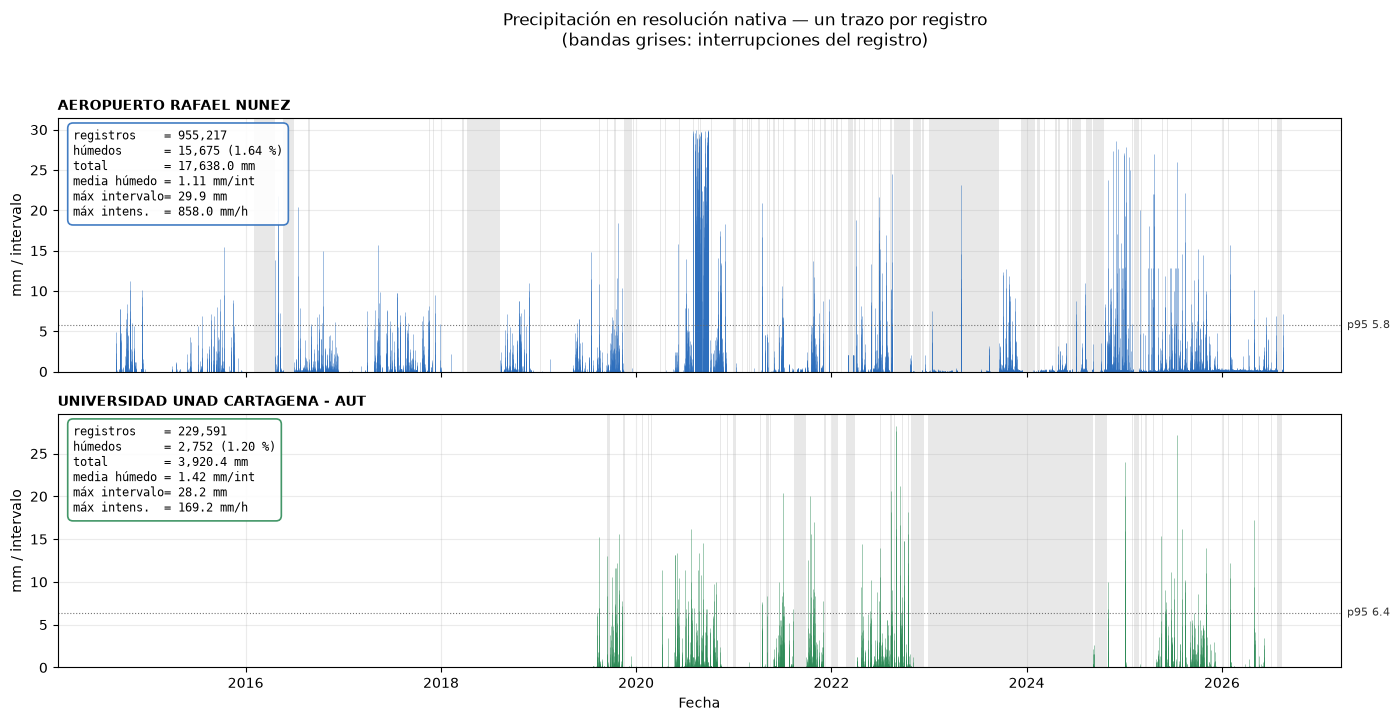

In [17]:
PALETA = ["#2E6FBD", "#2E8B57", "#C0562E", "#6A4C93"]
nombres = serie_pp["Estacion"].drop_duplicates().tolist()

fig, axes = plt.subplots(len(nombres), 1, figsize=(15, 3.6 * len(nombres)), sharex=True)
axes = np.atleast_1d(axes)

for ax, nombre, color in zip(axes, nombres, PALETA):
    sub = serie_pp[serie_pp["Estacion"] == nombre]
    hum = sub[sub["ValorObservado"] >= MM_INTERVALO_HUMEDO]
    d = descriptores.set_index("Estacion").loc[nombre]

    ax.scatter(hum["FechaObservacion"], hum["ValorObservado"],
               color=color, s=7, alpha=0.55, edgecolors="none")

    for _, hh in huecos[huecos["Estacion"] == nombre].iterrows():
        ax.axvspan(hh["ultimo_dato"], hh["siguiente_dato"],
                   color="#999", alpha=0.22, lw=0)

    ax.axhline(d["p95_humedo_mm"], color="#666", lw=0.8, ls=":", alpha=0.9)
    ax.annotate(f'p95 {d["p95_humedo_mm"]:.1f}', xy=(1.0, d["p95_humedo_mm"]),
                xycoords=("axes fraction", "data"), xytext=(4, 0),
                textcoords="offset points", va="center", ha="left", fontsize=8, color="#333")

    caja = (f'registros    = {int(d["n_registros"]):,}\n'
            f'húmedos      = {int(d["n_humedos"]):,} ({d["pct_intervalos_humedos"]:.2f} %)\n'
            f'total        = {d["pp_total_mm"]:,.1f} mm\n'
            f'media húmedo = {d["media_humedo_mm"]:.2f} mm/int\n'
            f'máx intervalo= {d["pp_max_intervalo"]:.1f} mm\n'
            f'máx intens.  = {d["intensidad_max_mmh"]:.1f} mm/h')
    ax.text(0.012, 0.96, caja, transform=ax.transAxes, fontsize=8.5,
            va="top", ha="left", family="monospace",
            bbox=dict(boxstyle="round,pad=0.45", facecolor="white",
                      edgecolor=color, alpha=0.9, linewidth=1.2))

    ax.set_title(nombre, fontsize=10, loc="left", fontweight="bold")
    ax.set_ylabel("mm / intervalo")
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.25)

axes[-1].set_xlabel("Fecha")
fig.suptitle("Precipitación en resolución nativa — eventos observados (gráfico de puntos)\n"
             "(bandas grises: interrupciones del registro)", fontsize=12, y=0.995)
plt.tight_layout(rect=[0, 0, 0.94, 0.97])
plt.show()

## 13. Limitaciones a declarar en el manuscrito

**Ausencia de estaciones en el área de estudio.** La estación más cercana está a ~8.96 km del borde del ROI.
**Intermitencia espacial de la lluvia convectiva.** La lluvia tropical en el Caribe ocurre en celdas convectivas de escala kilométrica; la correlación decae con la distancia más rápido que para la temperatura.
**Totales no corregidos por huecos.** Deben analizarse junto a la tabla de completitud anual.